<a href="https://colab.research.google.com/github/marcohinojosag/IA_MKTR/blob/branch-L/cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importación de librerias y carga del dataset
Quien necesita descargar en 2025, las APIs son el futuro 🗣🗣🗣

In [434]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter

In [435]:
# Sets path
test_path = "aps_failure_test_set.csv"
train_path = "aps_failure_training_set.csv"

# Load the latest version
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  test_path,
)

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  train_path,
)

Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.
Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.


#1. Analisis del dataset train


In [436]:
# Muestra de los datos
print(df.head(5))

  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [437]:
# Tamaño del dataset
print(df.shape)

(60000, 171)


In [438]:
# Se cambia la columna "class" a "clase"
df.rename(columns={'class': 'clase'}, inplace=True)

df.columns

Index(['clase', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [439]:
# Reemplazo de "na" por NaN
df = df.replace("na", np.nan)
df

,clase,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,NaN,0,NaN,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,NaN,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,NaN,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,neg,153002,NaN,664,186,0,0,0,0,0,...,998500,566884,1290398,1218244,1019768,717762,898642,28588,0,0
59996,neg,2286,NaN,2130706538,224,0,0,0,0,0,...,10578,6760,21126,68424,136,0,0,0,0,0
59997,neg,112,0,2130706432,18,0,0,0,0,0,...,792,386,452,144,146,2622,0,0,0,0
59998,neg,80292,NaN,2130706432,494,0,0,0,0,0,...,699352,222654,347378,225724,194440,165070,802280,388422,0,0


In [440]:
# Separacion de negativos y positivos
df_neg = df[df['clase'] == 'neg']
df_pos = df[df['clase'] == 'pos']

In [441]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df_neg)
cant_pos = len(df_pos)
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 59000, Positivos: 1000


# 2. Obtener columnas a eliminar por vacio

In [442]:
# Porcentaje de valores vacíos por columna
cv = df.isna().sum()/len(df)
cv_neg = df_neg.isna().sum()/cant_neg
cv_pos = df_pos.isna().sum()/cant_pos

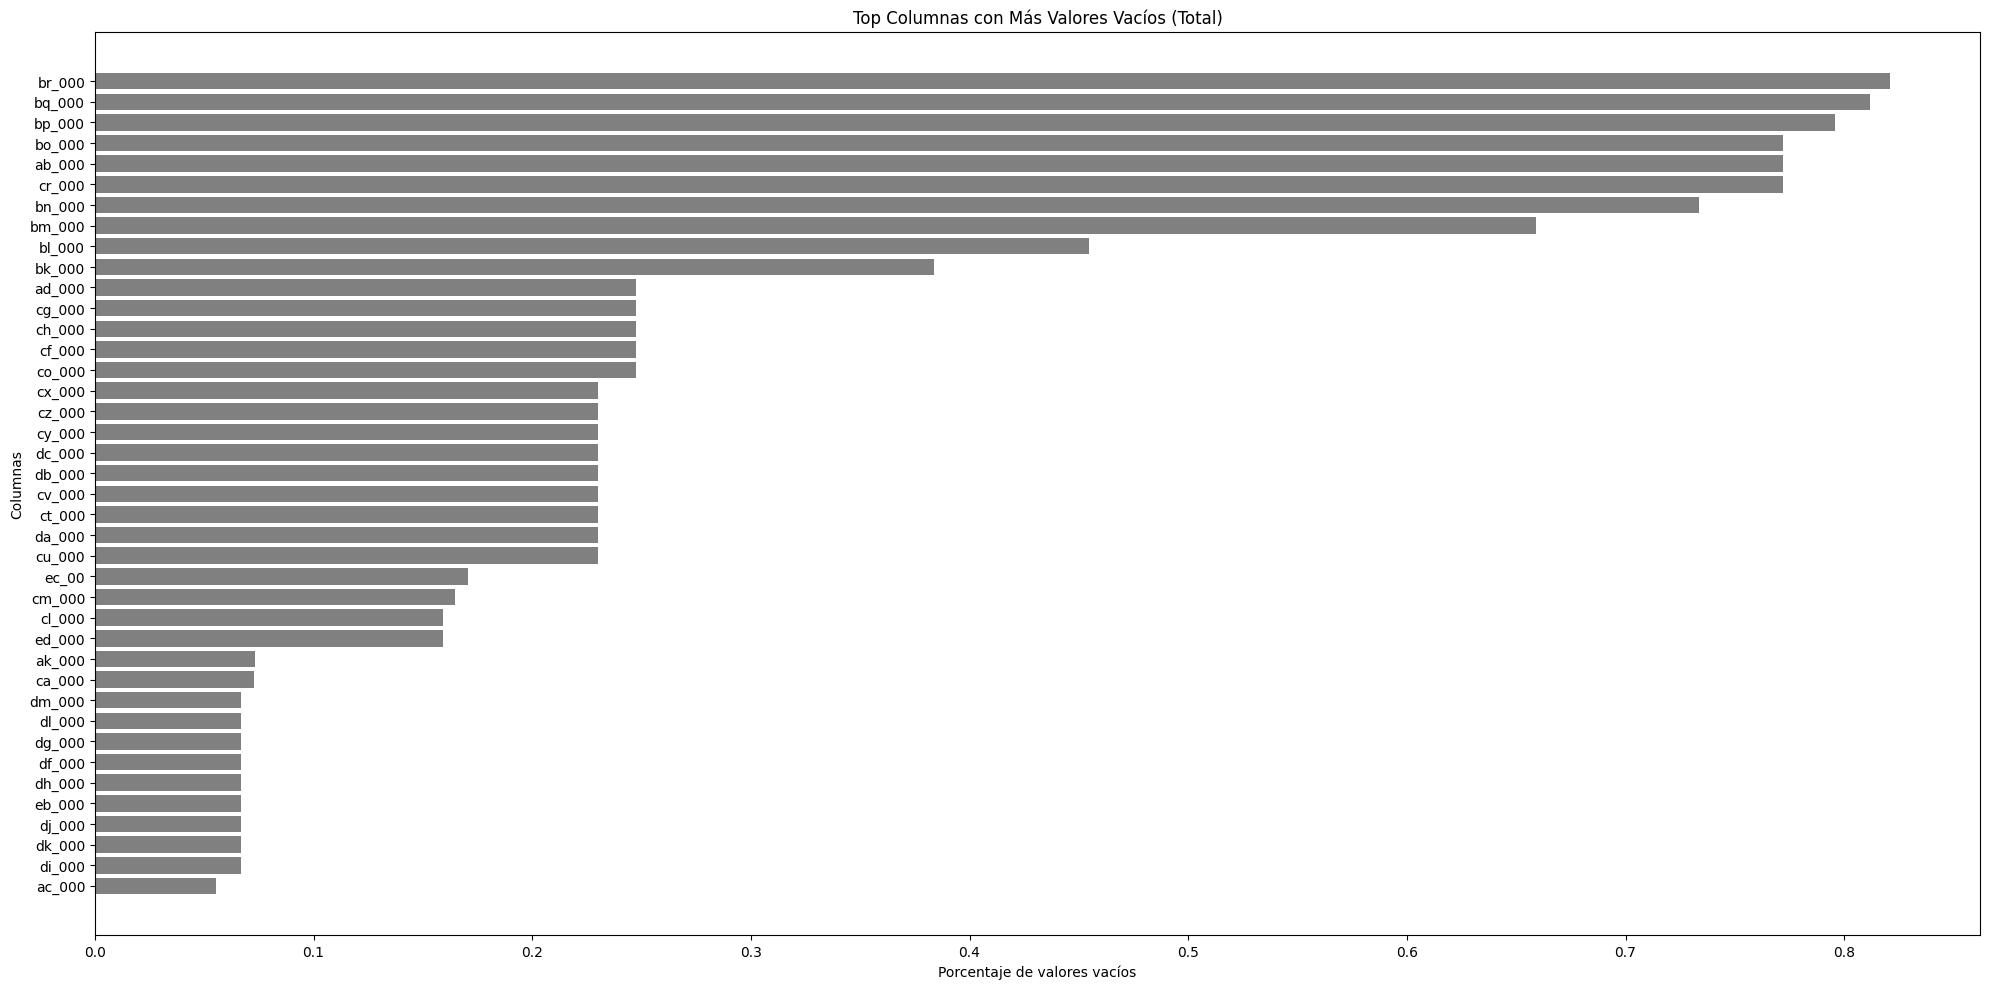

In [443]:
top = cv.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top.index[::-1], top.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Total)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

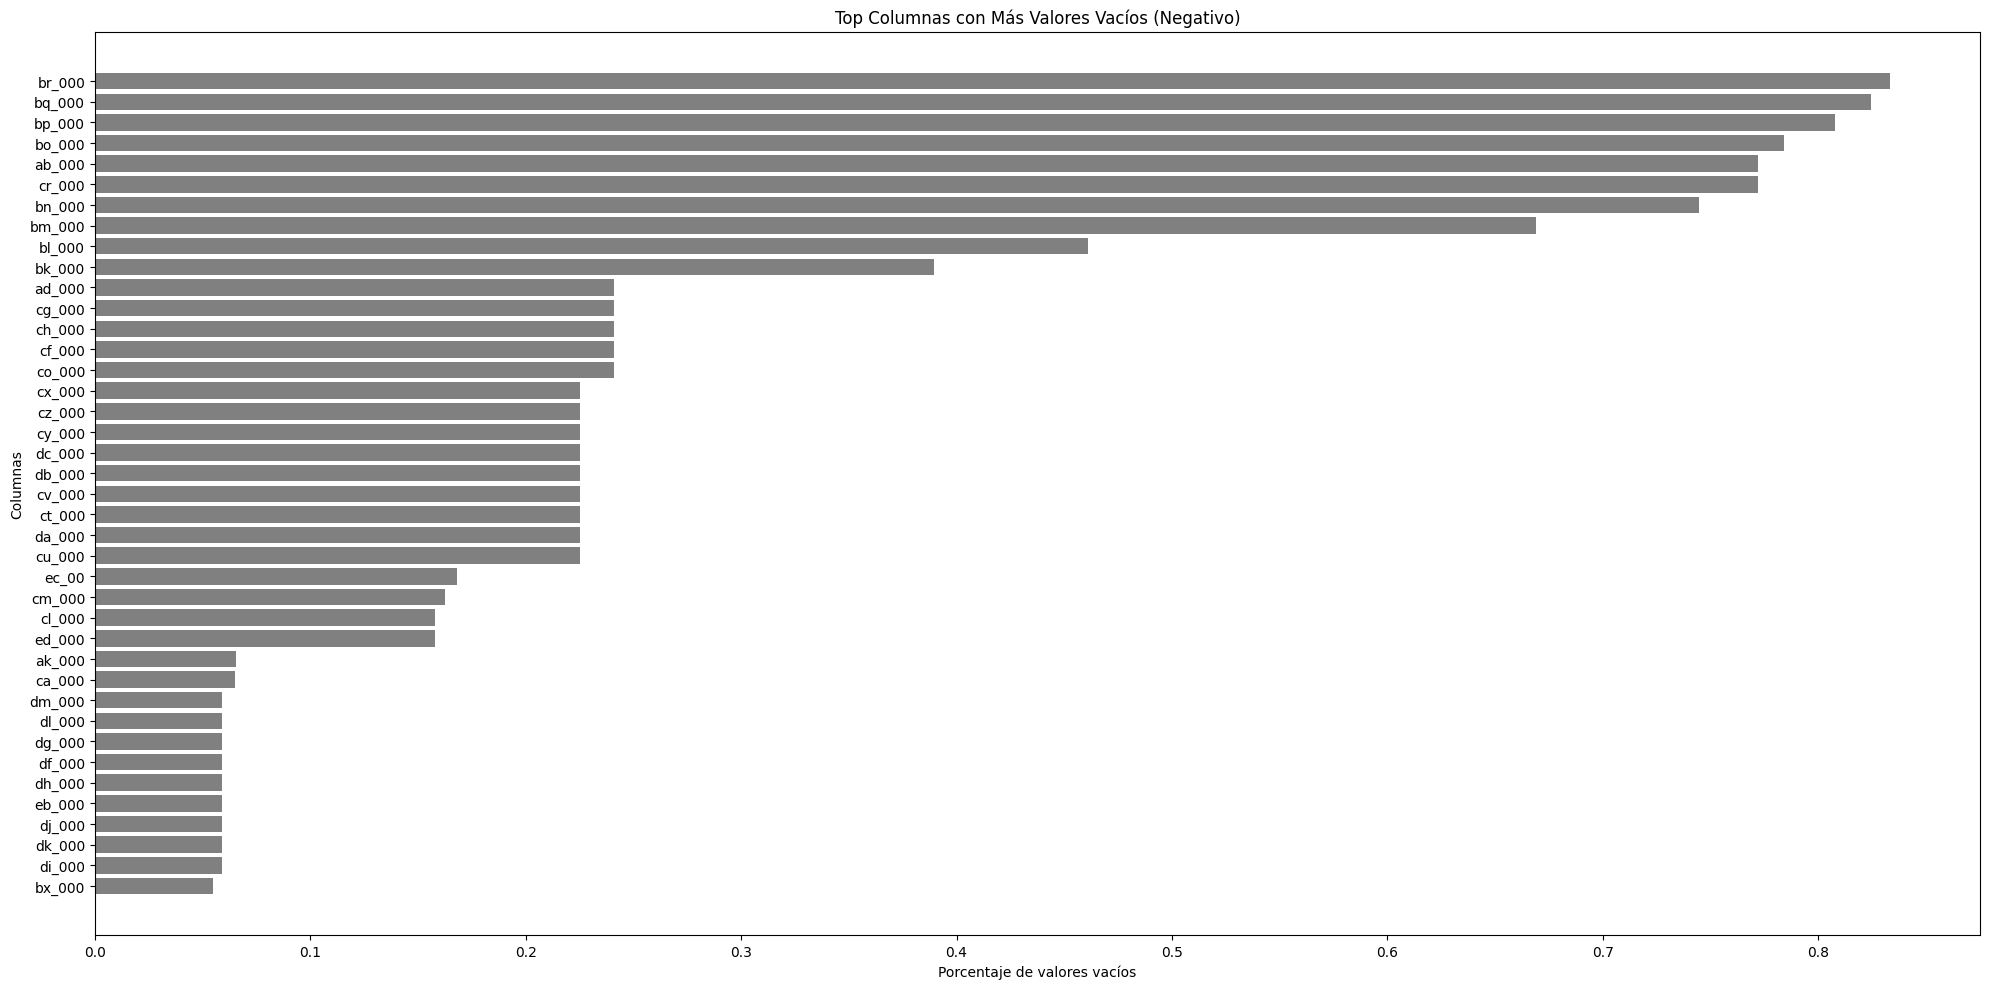

In [444]:
top_neg = cv_neg.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top_neg.index[::-1], top_neg.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Negativo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

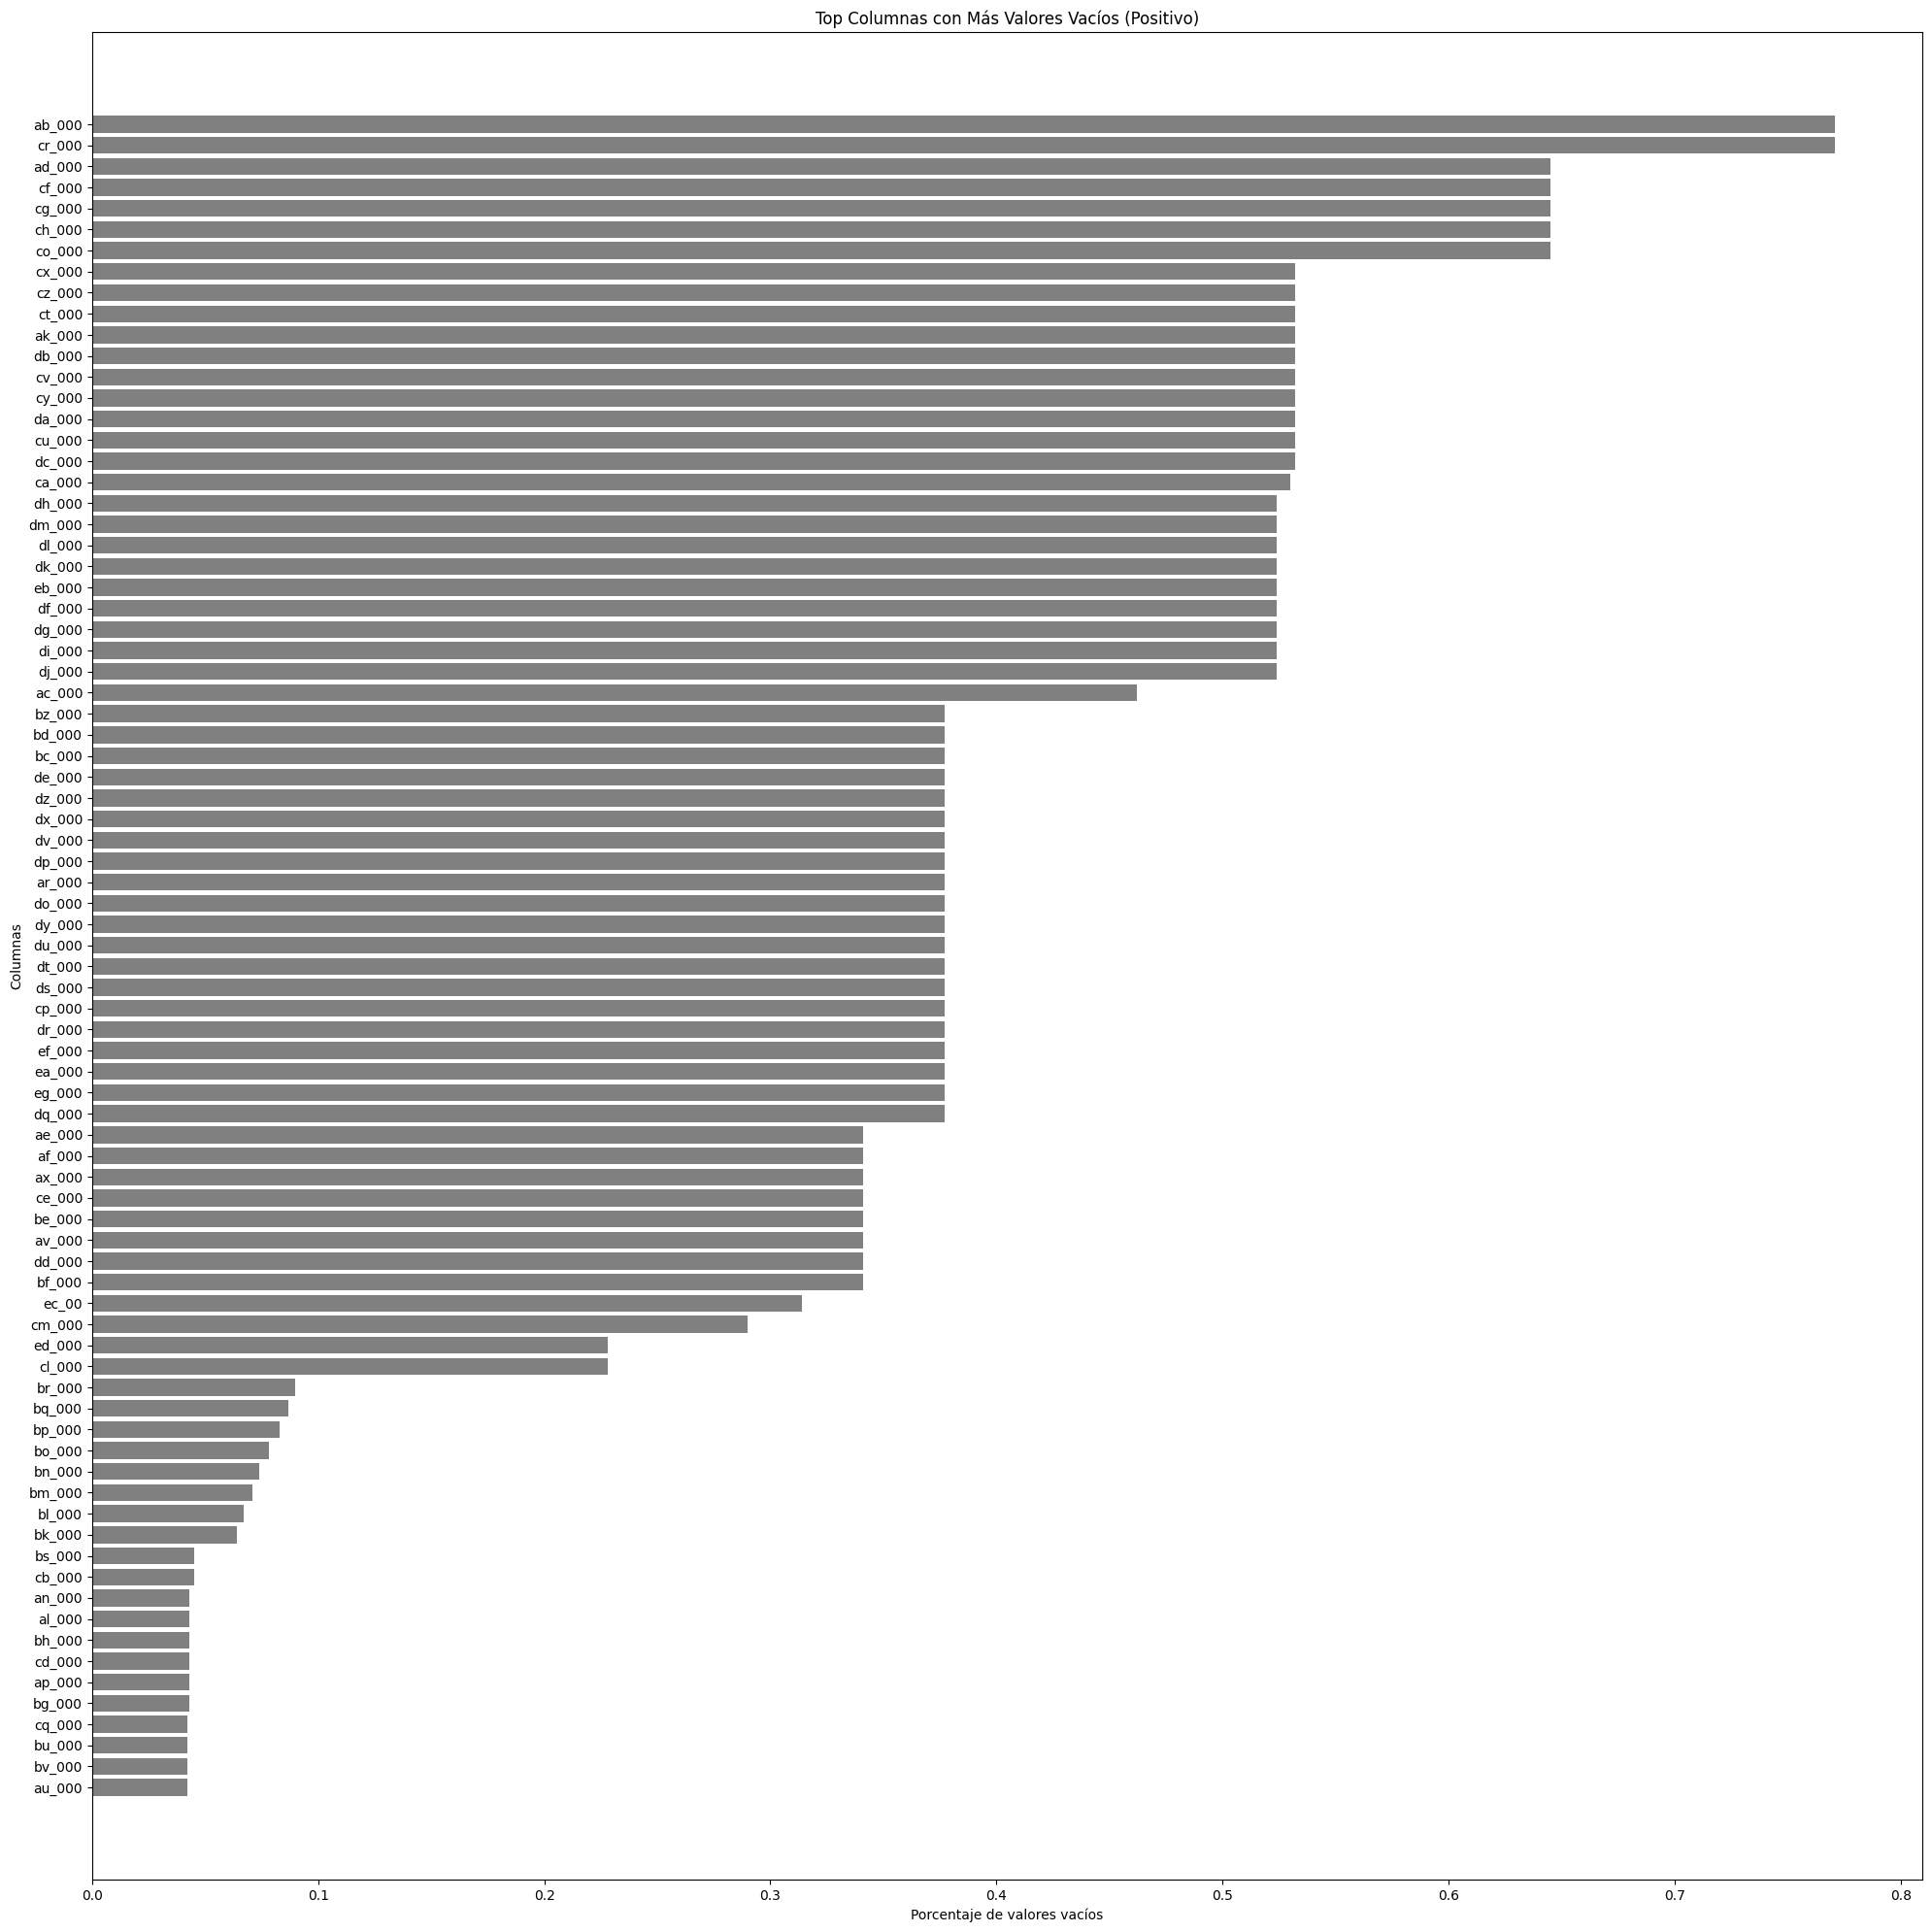

In [445]:
top_pos = cv_pos.sort_values(ascending=False).head(80)

plt.figure(figsize=(20, 20))
plt.barh(top_pos.index[::-1], top_pos.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Positivo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

#3. Limpieza del dataset train

In [446]:
# Columnas con más de 10% de "na"
umbral_total = 0.1
cols_total_umbral = cv[cv > umbral_total].index.tolist()
print("Columnas totales:")
print(cols_total_umbral)

# Columnas con más de 10% de "na"
umbral_pos = 0.1
cols_pos_umbral = cv_pos[cv_pos > umbral_pos].index.tolist()
print("Columnas positivas:")
print(cols_pos_umbral)

# Columnas con más de 10% de "na"
umbral_neg = 0.1
cols_neg_umbral = cv_neg[cv_neg > umbral_neg].index.tolist()
print("Columnas negativas:")
print(cols_neg_umbral)

Columnas totales:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'ec_00', 'ed_000']
Columnas positivas:
['ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ak_000', 'ar_000', 'av_000', 'ax_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bz_000', 'ca_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cp_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'dd_000', 'de_000', 'df_000', 'dg_000', 'dh_000', 'di_000', 'dj_000', 'dk_000', 'dl_000', 'dm_000', 'do_000', 'dp_000', 'dq_000', 'dr_000', 'ds_000', 'dt_000', 'du_000', 'dv_000', 'dx_000', 'dy_000', 'dz_000', 'ea_000', 'eb_000', 'ec_00', 'ed_000', 'ef_000', 'eg_000']
Columnas negativas:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', '

In [447]:
# Elemento comunes de lista de columnas a eliminar
cols_eliminar = list(set(cols_total_umbral) & set(cols_pos_umbral) & set(cols_neg_umbral))

# Eliminar columnas
df_clean = df.drop(columns=cols_eliminar)

df_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,2130706438,0,0,0,0,0,0,37250,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,0,0,0,0,0,0,0,18254,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,228,0,0,0,0,0,0,1648,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,70,0,10,0,0,0,318,2212,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,1368,0,0,0,0,0,0,43752,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,neg,153002,664,0,0,0,0,0,2564,59100,...,998500,566884,1290398,1218244,1019768,717762,898642,28588,0,0
59996,neg,2286,2130706538,0,0,0,0,0,0,104,...,10578,6760,21126,68424,136,0,0,0,0,0
59997,neg,112,2130706432,0,0,0,0,0,0,28,...,792,386,452,144,146,2622,0,0,0,0
59998,neg,80292,2130706432,0,0,0,0,0,0,330,...,699352,222654,347378,225724,194440,165070,802280,388422,0,0


In [448]:
# Cambiar negativos a 0 y positivos a 1
df_clean["clase"] = df_clean["clase"].map({"neg": 0, "pos": 1})

df_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,2130706438,0,0,0,0,0,0,37250,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,0,33058,0,0,0,0,0,0,0,18254,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,0,41040,228,0,0,0,0,0,0,1648,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,0,12,70,0,10,0,0,0,318,2212,...,240,46,58,44,10,0,0,0,4,32
4,0,60874,1368,0,0,0,0,0,0,43752,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,153002,664,0,0,0,0,0,2564,59100,...,998500,566884,1290398,1218244,1019768,717762,898642,28588,0,0
59996,0,2286,2130706538,0,0,0,0,0,0,104,...,10578,6760,21126,68424,136,0,0,0,0,0
59997,0,112,2130706432,0,0,0,0,0,0,28,...,792,386,452,144,146,2622,0,0,0,0
59998,0,80292,2130706432,0,0,0,0,0,0,330,...,699352,222654,347378,225724,194440,165070,802280,388422,0,0


In [449]:
# Cambiar tipo de dato
df_clean = df_clean.astype(float)
df_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0.0,76698.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0.0,33058.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0.0,41040.0,2.280000e+02,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0.0,12.0,7.000000e+01,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0.0,60874.0,1.368000e+03,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,153002.0,6.640000e+02,0.0,0.0,0.0,0.0,0.0,2564.0,59100.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,0.0,2286.0,2.130707e+09,0.0,0.0,0.0,0.0,0.0,0.0,104.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,112.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,0.0,80292.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,330.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


In [450]:
# Manejar los valores nulos
from sklearn.impute import SimpleImputer

df_imputado = df_clean.copy()

imputer = SimpleImputer(strategy="mean")
df_clean = pd.DataFrame(imputer.fit_transform(df_imputado), columns=df_imputado.columns)

df_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0.0,76698.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0.0,33058.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0.0,41040.0,2.280000e+02,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0.0,12.0,7.000000e+01,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0.0,60874.0,1.368000e+03,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,153002.0,6.640000e+02,0.0,0.0,0.0,0.0,0.0,2564.0,59100.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,0.0,2286.0,2.130707e+09,0.0,0.0,0.0,0.0,0.0,0.0,104.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,112.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,0.0,80292.0,2.130706e+09,0.0,0.0,0.0,0.0,0.0,0.0,330.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


In [451]:
# Normalizar
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df_norm = df_clean.copy()

scaler = MinMaxScaler()
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

df_clean[num_cols] = scaler.fit_transform(df_norm[num_cols])

df_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0.0,0.027925,9.999998e-01,0.0,0.000000,0.0,0.0,0.0,0.000000,1.627842e-04,...,0.015918,0.013067,7.421784e-03,8.179508e-03,1.073013e-02,0.001321,0.003800,0.000000,0.000000,0.000000
1,0.0,0.012036,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.000000,7.977081e-05,...,0.005407,0.004716,3.019031e-03,4.272917e-03,4.228511e-03,0.000679,0.005064,0.000394,0.000000,0.000000
2,0.0,0.014942,1.070067e-07,0.0,0.000000,0.0,0.0,0.0,0.000000,7.201835e-06,...,0.003559,0.004232,4.364196e-03,7.130884e-03,1.014768e-02,0.001321,0.004937,0.000135,0.000000,0.000000
3,0.0,0.000004,3.285295e-08,0.0,0.000498,0.0,0.0,0.0,0.000005,9.666541e-06,...,0.000003,0.000001,5.970003e-07,7.660803e-07,3.163775e-07,0.000000,0.000000,0.000000,0.008299,0.027923
4,0.0,0.022164,6.420405e-07,0.0,0.000000,0.0,0.0,0.0,0.000000,1.911982e-04,...,0.007981,0.006086,4.171776e-03,6.044861e-03,9.078578e-03,0.002605,0.022523,0.000320,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.055707,3.116337e-07,0.0,0.000000,0.0,0.0,0.0,0.000040,2.582697e-04,...,0.012812,0.015013,1.328221e-02,2.121074e-02,3.226316e-02,0.006002,0.046641,0.007503,0.000000,0.000000
59996,0.0,0.000832,9.999999e-01,0.0,0.000000,0.0,0.0,0.0,0.000000,4.544847e-07,...,0.000136,0.000179,2.174522e-04,1.191324e-03,4.302733e-06,0.000000,0.000000,0.000000,0.000000,0.000000
59997,0.0,0.000041,9.999998e-01,0.0,0.000000,0.0,0.0,0.0,0.000000,1.223613e-07,...,0.000010,0.000010,4.652485e-06,2.507172e-06,4.619111e-06,0.000022,0.000000,0.000000,0.000000,0.000000
59998,0.0,0.029234,9.999998e-01,0.0,0.000000,0.0,0.0,0.0,0.000000,1.442115e-06,...,0.008974,0.005897,3.575600e-03,3.930061e-03,6.151643e-03,0.001380,0.041639,0.101946,0.000000,0.000000


In [452]:
from sklearn.utils import resample

# Separacion de negativos y positivos
df_clean_neg = df_clean[df_clean['clase'] == 0]
df_clean_pos = df_clean[df_clean['clase'] == 1]

# Submuestreo de negativos (mismo tamaño que positivos)
df_neg_down = resample(df_clean_neg,
                       replace=False,     # sin reemplazo
                       n_samples=10*len(df_pos),
                       random_state=42)

# Nuevo dataset balanceado
df_clean = pd.concat([df_clean_pos, df_neg_down])

#4. Procesar dataset test

In [453]:

test.rename(columns={'class': 'clase'}, inplace=True)

test_clean = test.replace("na", np.nan)

test_clean = test_clean.drop(columns=cols_eliminar)

test_clean["clase"] = test_clean["clase"].map({"neg": 0, "pos": 1})

test_clean = test_clean.astype(float)

test_clean = pd.DataFrame(imputer.transform(test_clean), columns=test_clean.columns)

test_clean[num_cols] = scaler.transform(test_clean[num_cols])

test_clean

,clase,aa_000,ac_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0.0,0.000022,9.386557e-09,0.000000,0.000000,0.0,0.0,0.0,0.000042,2.069654e-05,...,1.408886e-05,3.654817e-06,4.240761e-06,1.138674e-05,2.467744e-06,7.359084e-07,0.000000,0.000000,0.0,0.0
1,0.0,0.000030,3.191429e-08,0.000000,0.000000,0.0,0.0,0.0,0.000000,3.268794e-06,...,1.370392e-05,7.309634e-06,1.667484e-05,2.019666e-06,2.720846e-06,3.863519e-06,0.000000,0.000000,0.0,0.0
2,0.0,0.024031,9.949750e-08,0.000000,0.000000,0.0,0.0,0.0,0.003146,5.936864e-03,...,6.352509e-03,1.007373e-02,4.530347e-03,4.693217e-03,4.160433e-02,1.285164e-03,0.000027,0.000000,0.0,0.0
3,0.0,0.021778,4.740211e-07,0.000000,0.000000,0.0,0.0,0.0,0.000000,5.415448e-04,...,6.939468e-03,6.442806e-03,4.974680e-03,8.450074e-03,1.364776e-02,1.756764e-03,0.014619,0.000848,0.0,0.0
4,0.0,0.000660,7.321514e-08,0.000000,0.000000,0.0,0.0,0.0,0.000000,3.146433e-07,...,9.810875e-05,1.097504e-04,1.900725e-04,8.667502e-04,1.004815e-04,4.030771e-06,0.000004,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,0.0,0.029802,9.999998e-01,0.000000,0.000000,0.0,0.0,0.0,0.000000,2.397407e-05,...,8.117877e-03,7.236590e-03,5.253129e-03,6.510254e-03,1.106815e-02,2.657967e-03,0.049826,0.006710,0.0,0.0
15996,0.0,0.000007,2.440505e-08,0.000380,0.001295,0.0,0.0,0.0,0.000000,2.816057e-05,...,3.413148e-06,1.165304e-06,4.734830e-07,2.437528e-07,6.327549e-08,0.000000e+00,0.000000,0.000000,0.0,0.0
15997,0.0,0.028995,7.837775e-07,0.000000,0.000000,0.0,0.0,0.0,0.000000,6.582163e-05,...,1.035277e-02,1.191687e-02,8.016541e-03,1.012546e-02,1.187991e-02,1.863738e-03,0.018629,0.005131,0.0,0.0
15998,0.0,0.000040,1.689580e-08,0.000000,0.000000,0.0,0.0,0.0,0.000000,8.652690e-07,...,7.544853e-06,5.561678e-06,1.852760e-06,9.471538e-06,3.176430e-05,1.118915e-05,0.000004,0.000000,0.0,0.0


#5. Entrenamiento del modelo

In [454]:
x_train = df_clean.drop(columns=['clase'])
y_train = df_clean['clase']

x_test  = test_clean.drop(columns=['clase'])
y_test  = test_clean['clase']

In [455]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import time

# Inicialización y entrenamiento del modelo
model = RandomForestClassifier(random_state=100)

start = time.time()

# Entrenar
model.fit(x_train, y_train)

end = time.time()

print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

# Predecir
y_pred = model.predict(x_test)

Tiempo de entrenamiento: 17.13 segundos


In [456]:
# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9866
Precision: 0.6545
Recall: 0.9093
F1-score: 0.7612


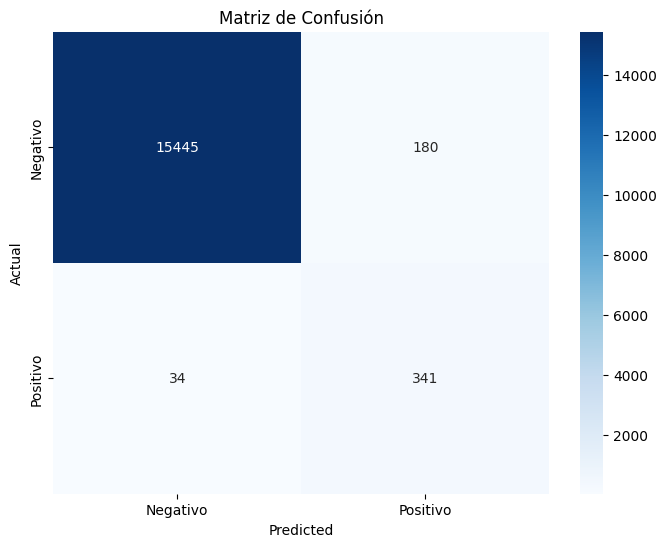

In [457]:
# 3. Evaluación
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

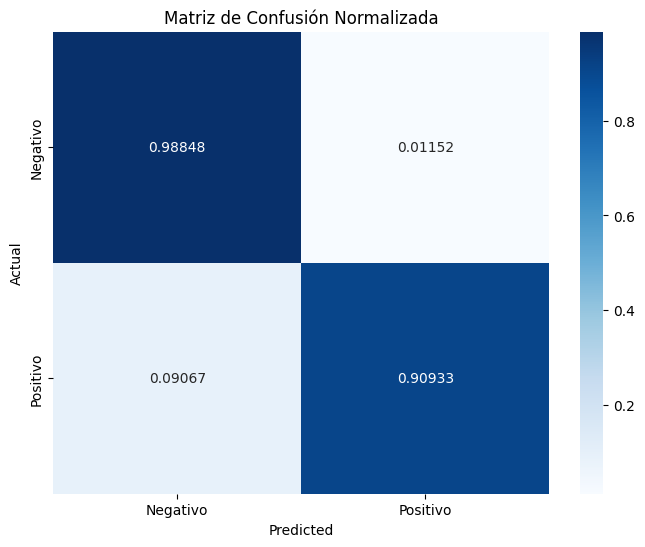

In [458]:
# Normalizar por fila (dividir cada valor por el total real de la clase)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.5f', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión Normalizada')
plt.show()

In [459]:
# Definir los costos
Cost_1 = 10  # Revisión innecesaria
Cost_2 = 500  # No detectar falla

# Extraer los valores de la matriz de confusión
TP = cm[1, 1]  # True Positives
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives

# Calcular el coste total
Total_cost = Cost_1 * FP + Cost_2 * FN
print(f"Numero de revisiones innecesarias: {FP}")
print(f"Numero de fallas no detectadas: {FN}")
print(f"Costo total: {Total_cost:.2f}")

Numero de revisiones innecesarias: 180
Numero de fallas no detectadas: 34
Costo total: 18800.00
